### Notebook 27

# **Regions of Interest Tables and Figures**

## **1. Tables**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from nilearn import image, datasets
from skimage.transform import resize

In [2]:
# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [3]:
# Load the general results for the ROI analysis. 
with open(results_path + 'regions_of_interest/general_results.p', 'rb') as file:
    general_results = pickle.load(file)

# Store the results into variables. 
df_summary_ml_class_pooled = general_results['df_summary_ml_class_pooled']
df_summary_ml_reg_pooled = general_results['df_summary_ml_reg_pooled']
df_summary_dl_class_pooled = general_results['df_summary_dl_class_pooled']
df_summary_dl_reg_pooled = general_results['df_summary_dl_reg_pooled']
df_summary_foundation_models_8_regions = general_results['df_summary_foundation_models_8_regions']
df_summary_foundation_models_5_regions = general_results['df_summary_foundation_models_5_regions']

In [4]:
# Concatenate the classification summary DataFrames for machine learning and deep learning models. 
df_summary_class_pooled = pd.concat([df_summary_ml_class_pooled, df_summary_dl_class_pooled])

# Remove the Background region from the classification summary DataFrame.
df_summary_class_pooled = df_summary_class_pooled[df_summary_class_pooled.index.get_level_values('brain region') != 'Background']
df_summary_class_pooled

N  \
model               brain region                                    
Logistic Regression Frontal Pole                               27   
                    Insular Cortex                             27   
                    Superior Frontal Gyrus                     27   
                    Middle Frontal Gyrus                       27   
                    Inferior Frontal Gyrus, pars triangularis  27   
...                                                            ..   
Transformer         Planum Polare                              27   
                    Heschl's Gyrus (includes H1 and H2)        27   
                    Planum Temporale                           27   
                    Supracalcarine Cortex                      27   
                    Occipital Pole                             27   

                                                              mean model accuracy  \
model               brain region                                                    
Logistic Regression Frontal Pole                                         0.520809   
                    Insular Cortex                                         0.5168   
                    Superior Frontal Gyrus                               0.520237   
                    Middle Frontal Gyrus                                 0.527873   
                    Inferior Frontal Gyrus, pars triangularis            0.502673   
...                                                                           ...   
Transformer         Planum Polare                                        0.504391   
                    Heschl's Gyrus (includes H1 and H2)                    0.5021   
                    Planum Temporale                                     0.506109   
                    Supracalcarine Cortex                                0.507446   
                    Occipital Pole                                       0.501527   

                                                              mean baseline accuracy  \
model               brain region                                                       
Logistic Regression Frontal Pole                                            0.511264   
                    Insular Cortex                                          0.522719   
                    Superior Frontal Gyrus                                  0.518328   
                    Middle Frontal Gyrus                                    0.512218   
                    Inferior Frontal Gyrus, pars triangularis               0.503818   
...                                                                              ...   
Transformer         Planum Polare                                           0.506682   
                    Heschl's Gyrus (includes H1 and H2)                     0.517373   
                    Planum Temporale                                        0.507064   
                    Supracalcarine Cortex                                   0.494654   
                    Occipital Pole                                          0.507255   

                                                              STD model accuracy  \
model               brain region                                                   
Logistic Regression Frontal Pole                                        0.048492   
                    Insular Cortex                                      0.033516   
                    Superior Frontal Gyrus                              0.036419   
                    Middle Frontal Gyrus                                0.037913   
                    Inferior Frontal Gyrus, pars triangularis           0.028463   
...                                                                          ...   
Transformer         Planum Polare                                       0.026233   
                    Heschl's Gyrus (includes H1 and H2)                 0.035317   
                    Planum Temporale                                    0.0

In [5]:
# Concatenate the regression summary DataFrames for machine learning and deep learning models. 
df_summary_reg_pooled = pd.concat([df_summary_ml_reg_pooled, df_summary_dl_reg_pooled])

# Remove the Ridge and Lasso models from the regression summary DataFrame. 
df_summary_reg_pooled = df_summary_reg_pooled[~df_summary_reg_pooled.index.get_level_values('model').isin(['Ridge Regression', 'Lasso Regression'])]

# Remove the Background region from the regression summary DataFrame.
df_summary_reg_pooled = df_summary_reg_pooled[df_summary_reg_pooled.index.get_level_values('brain region') != 'Background']
df_summary_reg_pooled

N  \
model             brain region                                    
Linear Regression Frontal Pole                               27   
                  Insular Cortex                             27   
                  Superior Frontal Gyrus                     27   
                  Middle Frontal Gyrus                       27   
                  Inferior Frontal Gyrus, pars triangularis  27   
...                                                          ..   
Transformer       Planum Polare                              27   
                  Heschl's Gyrus (includes H1 and H2)        27   
                  Planum Temporale                           27   
                  Supracalcarine Cortex                      27   
                  Occipital Pole                             27   

                                                            mean model MAE  \
model             brain region                                               
Linear Regression Frontal Pole                                    0.905702   
                  Insular Cortex                                  0.894583   
                  Superior Frontal Gyrus                          0.855446   
                  Middle Frontal Gyrus                            0.904246   
                  Inferior Frontal Gyrus, pars triangularis        0.93264   
...                                                                    ...   
Transformer       Planum Polare                                   0.784712   
                  Heschl's Gyrus (includes H1 and H2)             0.784687   
                  Planum Temporale                                 0.76632   
                  Supracalcarine Cortex                           0.799185   
                  Occipital Pole                                  0.785974   

                                                            mean baseline MAE  \
model             brain region                                                  
Linear Regression Frontal Pole                                        0.72948   
                  Insular Cortex                                     0.754798   
                  Superior Frontal Gyrus                             0.719737   
                  Middle Frontal Gyrus                               0.734678   
                  Inferior Frontal Gyrus, pars triangularis          0.752245   
...                                                                       ...   
Transformer       Planum Polare                                       0.77202   
                  Heschl's Gyrus (includes H1 and H2)                0.766299   
                  Planum Temporale                                   0.759918   
                  Supracalcarine Cortex                              0.799145   
                  Occipital Pole                                     0.793852   

                                                            STD model MAE  \
model             brain region                                              
Linear Regression Frontal Pole                                   0.165448   
                  Insular Cortex                                 0.124419   
                  Superior Frontal Gyrus                         0.157173   
                  Middle Frontal Gyrus                           0.132882   
                  Inferior Frontal Gyrus, pars triangularis      0.140868   
...                                                                   ...   
Transformer       Planum Polare                                  0.072543   
                  Heschl's Gyrus (includes H1 and H2)            0.065722   
                  Planum Temporale                               0.040772   
                  Supracalcarine Cortex                          0.073807   
                  Occipital Pole                                 0.052904   

                                                            STD baseline MAE  \
model             brain region         

In [6]:
# Define a function to format the tables for machine learning and deep learning models. 
def format_table(df_summary, model_names, model_abbreviations, brain_regions):

    # Create a table comparing the RBC between brain regions (rows) and models (columns). 
    table_rbc = df_summary.pivot_table(values = 'RBC', index = 'brain region', columns = 'model')

    # Reorder the brain regions and the models. 
    table_rbc = table_rbc.reindex(index = brain_regions, columns = model_names)

    # Rename the models. 
    table_rbc.columns = model_abbreviations

    # Rename the index to 'Brain Region'. 
    table_rbc.index.name = 'Brain Region'

    # Add a new column with the mean RBC across models for each brain region. 
    table_rbc['MEAN REGION'] = table_rbc.mean(axis = 1)

    # Sort the table by the mean RBC in descending order. 
    table_rbc = table_rbc.sort_values(by = 'MEAN REGION', ascending = False)

    # Add a new row with the mean RBC across brain regions for each model. 
    table_rbc.loc['MEAN MODEL'] = table_rbc.mean(axis = 0)

    # Convert the RBC values to numeric, then keep only three decimal places for all values. 
    table_rbc = table_rbc.apply(pd.to_numeric)
    table_rbc = table_rbc.round(3)

    return table_rbc

In [7]:
# Store the brain regions and models lists. 
brain_regions = df_summary_class_pooled.index.get_level_values('brain region').unique().tolist()
model_names_class = df_summary_class_pooled.index.get_level_values('model').unique().tolist()
model_names_reg = df_summary_reg_pooled.index.get_level_values('model').unique().tolist()
model_names_fm_8_regions = df_summary_foundation_models_8_regions.index.get_level_values('model').unique().tolist()
model_names_fm_5_regions = df_summary_foundation_models_5_regions.index.get_level_values('model').unique().tolist()

In [8]:
# Format the classification table. 
model_abbreviations_class = ['Logistic', 'KNN', 'DT', 'RF', 'SVM', 'XGB', 'MLP', 'CNN', 'RNN', 'Transformer']
table_rbc_class = format_table(df_summary_class_pooled, model_names_class, model_abbreviations_class, brain_regions)

# Save and display the DataFrame. 
table_rbc_class.to_csv(results_path + 'table_roi_classification.csv', index = True)
table_rbc_class

,Logistic,KNN,DT,RF,SVM,XGB,MLP,CNN,RNN,Transformer,MEAN REGION
Brain Region,,,,,,,,,,,
Cuneal Cortex,0.883,0.806,0.606,0.897,1.000,0.974,0.735,0.607,0.877,0.620,0.801
Intracalcarine Cortex,0.915,0.638,0.687,0.923,0.934,0.810,0.951,0.565,0.567,0.577,0.757
"Inferior Temporal Gyrus, posterior division",0.646,0.587,0.766,0.797,0.854,0.600,0.786,0.681,0.891,0.729,0.734
"Lateral Occipital Cortex, inferior division",0.701,0.714,0.571,0.745,0.727,0.519,0.875,0.233,0.610,0.542,0.624
Subcallosal Cortex,0.812,0.535,0.703,0.534,0.557,0.598,0.578,0.601,0.686,0.511,0.612
"Inferior Temporal Gyrus, temporooccipital part",0.622,0.556,0.348,0.733,0.738,0.741,0.613,0.446,0.595,0.433,0.582
"Middle Temporal Gyrus, posterior division",0.492,0.647,0.381,0.652,0.714,0.510,0.593,0.286,0.429,0.579,0.528
Occipital Fusiform Gyrus,0.606,0.425,0.372,0.405,0.840,0.577,0.812,-0.140,0.696,0.513,0.510
"Lateral Occipital Cortex, superior division",0.640,0.249,0.554,0.480,0.733,0.587,0.877,0.102,0.403,0.179,0.481


In [9]:
# Format the regression table. 
model_abbreviations_reg = ['Linear', 'KNN', 'DT', 'RF', 'SVM', 'XGB', 'MLP', 'CNN', 'RNN', 'Transformer']
table_rbc_reg = format_table(df_summary_reg_pooled, model_names_reg, model_abbreviations_reg, brain_regions)

# Save and display the DataFrame. 
table_rbc_reg.to_csv(results_path + 'table_roi_regression.csv', index = True)
table_rbc_reg

,Linear,KNN,DT,RF,SVM,XGB,MLP,CNN,RNN,Transformer,MEAN REGION
Brain Region,,,,,,,,,,,
"Inferior Temporal Gyrus, posterior division",-0.222,-0.323,-0.598,0.148,0.344,-0.349,-0.254,0.323,0.085,0.354,-0.049
Cuneal Cortex,-0.286,0.016,-0.698,0.317,0.640,-0.307,-0.265,-0.265,-0.413,0.296,-0.096
"Inferior Frontal Gyrus, pars opercularis",-0.889,-0.148,-0.704,0.312,0.614,-0.476,0.069,0.455,-0.127,-0.074,-0.097
Frontal Medial Cortex,-0.646,-0.143,-0.418,0.550,0.333,-0.365,-0.042,-0.206,-0.079,-0.053,-0.107
Intracalcarine Cortex,-0.312,-0.333,-0.519,0.317,0.545,-0.492,-0.439,-0.037,-0.317,0.450,-0.114
"Lateral Occipital Cortex, inferior division",-0.540,-0.513,-0.624,0.249,0.270,-0.571,-0.312,0.344,0.042,0.312,-0.134
Occipital Fusiform Gyrus,-0.762,-0.508,-0.709,0.423,0.349,-0.640,-0.048,0.265,-0.180,0.122,-0.169
"Middle Temporal Gyrus, posterior division",-0.524,-0.434,-0.582,-0.048,0.291,-0.545,-0.164,0.302,-0.085,0.095,-0.169
"Inferior Temporal Gyrus, temporooccipital part",-0.450,-0.317,-0.772,0.011,0.333,-0.714,-0.265,0.180,-0.063,0.344,-0.171


In [10]:
# Retrieve the brain regions for the foundation models with 8 regions. 
brain_regions_fm_8_regions = df_summary_foundation_models_8_regions.index.get_level_values('brain region').unique().tolist()

# Format the table for the foundation models with 8 regions. 
model_abbreviations_fm_8_regions = model_names_fm_8_regions
table_rbc_fm_8_regions = format_table(df_summary_foundation_models_8_regions, model_names_fm_8_regions, model_abbreviations_fm_8_regions, brain_regions_fm_8_regions)

# Save and display the DataFrame. 
table_rbc_fm_8_regions.to_csv(results_path + 'table_roi_foundation_models_8_regions.csv', index = True)
table_rbc_fm_8_regions

,Gemma,Llama,PaliGemma,Gemma 5-Channel,MEAN REGION
Brain Region,,,,,
Frontal Pole,0.467,0.289,-0.733,0.244,0.067
Superior Parietal Lobule,0.378,0.156,-0.467,-0.200,-0.033
Insular Cortex,-0.022,-0.378,0.333,-0.467,-0.133
Occipital Pole,0.600,-0.244,-0.511,-0.422,-0.144
Angular Gyrus,0.067,0.156,-0.644,-0.333,-0.189
"Inferior Frontal Gyrus, pars triangularis",-0.111,0.067,-0.600,-0.378,-0.256
"Superior Temporal Gyrus, posterior division",0.022,-0.333,-0.733,-0.244,-0.322
Precentral Gyrus,-0.244,-0.333,-0.600,-0.244,-0.356
MEAN MODEL,0.144,-0.078,-0.494,-0.256,-0.171


In [11]:
# Retrieve the brain regions for the foundation models with 5 regions. 
brain_regions_fm_5_regions = df_summary_foundation_models_5_regions.index.get_level_values('brain region').unique().tolist()

# Format the table for the foundation models with 5 regions. 
model_abbreviations_fm_5_regions = ['Gemma CoT', 'Gemma without FT', 'Gemma with FT']
table_rbc_fm_5_regions = format_table(df_summary_foundation_models_5_regions, model_names_fm_5_regions, model_abbreviations_fm_5_regions, brain_regions_fm_5_regions)

# Save and display the DataFrame. 
table_rbc_fm_5_regions.to_csv(results_path + 'table_roi_foundation_models_5_regions.csv', index = True)
table_rbc_fm_5_regions

,Gemma CoT,Gemma without FT,Gemma with FT,MEAN REGION
Brain Region,,,,
Precentral Gyrus,0.644,0.467,0.422,0.511
Superior Parietal Lobule,-0.156,0.289,0.556,0.230
Occipital Pole,0.289,-0.111,0.156,0.111
"Superior Temporal Gyrus, posterior division",0.022,0.156,0.111,0.096
Frontal Pole,-0.067,0.200,-0.378,-0.081
MEAN MODEL,0.147,0.200,0.173,0.173


## **2. Figures**

In [12]:
# Define the fmriprep data path. 
fmriprep_data_path = '../../Neuropolis/neuropolis_fmriprep_data/'

In [13]:
# Define a function to return the middle sections of an image data array. 
def middle_sections(image_data):
    return tuple((np.array(image_data[:, :, :].shape) / 2).astype(int))

In [14]:
# Define a function to display sections of an image through the sagittal, coronal, and axial views, using the middle sections coordinates. 
def display_fMRI_atlas(image_data, colormap, scan = 0):
    fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 5))

    # Define the display size for resizing. 
    display_size = (256, 256)
    
    # If the image_data array contains several scans, select the scan given as argument. 
    if len(image_data.shape) == 4:
        image_data = image_data[:, :, :, scan]

    # Tighthen the image by removing borders. 
    image_data = image_data[3:-3, 2:-2, 4:-4]

    # Find the middle sections coordinates of the image data array. 
    middle_coord = middle_sections(image_data[:, :, :])

    # Extract slices. 
    sagittal = image_data[middle_coord[0], :, :].T
    coronal  = image_data[:, middle_coord[1], :].T
    axial    = image_data[:, :, middle_coord[2] - 1] # Improve the axial view centering.

    # Resize each slice to the same pixel dimensions. 
    sagittal_r = resize(sagittal, display_size, order = 0, preserve_range = True)
    coronal_r  = resize(coronal,  display_size, order = 0, preserve_range = True)
    axial_r    = resize(axial,    display_size, order = 0, preserve_range = True)

    # Assign NaN to regions equal to zero. 
    sagittal_r[sagittal_r == 0] = np.nan
    coronal_r[coronal_r == 0] = np.nan
    axial_r[axial_r == 0] = np.nan

    # Display the figure. 
    axes[0].imshow(sagittal_r, cmap = colormap, origin = 'lower')
    axes[0].set_title('Sagittal view')
    axes[0].axis('off')
    axes[1].imshow(coronal_r, cmap = colormap, origin = 'lower')
    axes[1].set_title('Coronal view')
    axes[1].axis('off')
    axes[2].imshow(axial_r, cmap = colormap, origin = 'lower')
    axes[2].set_title('Axial view')
    axes[2].axis('off');

In [15]:
# Define a function to display sections of an image through the sagittal, coronal, and axial views, using the middle sections coordinates, for three models. 
def display_fMRI_atlas_3_models(image_data_list, model_names, model_name_positions, colormap, scan = 0):
    fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (10, 10))

    # Define the display size for resizing.
    display_size = (256, 256)

    # Iterate through the three models. 
    for model_index, image_data in enumerate(image_data_list):

        # If the image_data array contains several scans, select the scan given as argument. 
        if len(image_data.shape) == 4:
            image_data = image_data[:, :, :, scan]
        
        # Tighthen the image by removing borders. 
        image_data = image_data[3:-3, 2:-2, 4:-4]

        # Find the middle sections coordinates of the image data array. 
        middle_coord = middle_sections(image_data[:, :, :])

        # Find the minimum and maximum RBC values of the model for the colormap scaling. 
        min_rbc = np.nanmin(image_data)
        max_rbc = np.nanmax(image_data)

        # Extract slices. 
        sagittal = image_data[middle_coord[0], :, :].T
        coronal  = image_data[:, middle_coord[1], :].T
        axial    = image_data[:, :, middle_coord[2] - 1] # Improve the axial view centering.

        # Resize each slice to the same pixel dimensions. 
        sagittal_r = resize(sagittal, display_size, order = 0, preserve_range = True)
        coronal_r  = resize(coronal,  display_size, order = 0, preserve_range = True)
        axial_r    = resize(axial,    display_size, order = 0, preserve_range = True)

        # Assign NaN to regions equal to zero. 
        sagittal_r[sagittal_r == 0] = np.nan
        coronal_r[coronal_r == 0] = np.nan
        axial_r[axial_r == 0] = np.nan

        # Add row label for model name. 
        fig.text(
            0.08,                                           # x position
            model_name_positions[model_index],              # y position
            model_names[model_index],
            va = 'center', ha = 'right', rotation = 90,
            fontsize = 12, fontweight = 'bold'
        )

        # Display the figure. 
        axes[model_index, 0].imshow(sagittal_r, cmap = colormap, origin = 'lower', vmin = min_rbc, vmax = max_rbc)
        #axes[model_index, 0].set_title('Sagittal')
        axes[model_index, 0].axis('off')
        axes[model_index, 1].imshow(coronal_r, cmap = colormap, origin = 'lower', vmin = min_rbc, vmax = max_rbc)
        #axes[model_index, 1].set_title('Coronal')
        axes[model_index, 1].axis('off')
        axes[model_index, 2].imshow(axial_r, cmap = colormap, origin = 'lower', vmin = min_rbc, vmax = max_rbc)
        #axes[model_index, 2].set_title('Axial')
        axes[model_index, 2].axis('off')
        
        # Add column labels for the neurological views. 
        if model_index == 0:
            fig.text(0.24, 0.9, 'Sagittal view', ha = 'center', fontsize = 12)
            fig.text(0.51,  0.9, 'Coronal view',  ha = 'center', fontsize = 12)
            fig.text(0.785, 0.9, 'Axial view',    ha = 'center', fontsize = 12);
    
        # Save the figure. 
        fig.savefig(results_path + 'figure_brain_maps.pdf', format = 'pdf', bbox_inches = 'tight')

In [16]:
# Load the Harvard-Oxford atlas for cortical regions. 
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr0-2mm', data_dir = None, symmetric_split = False, resume = True, verbose = 0)

# Extract the atlas as a Nifti image. 
atlas_img = image.load_img(atlas.maps)

# Extract the atlas data, and display its size. 
atlas_data = atlas.maps.get_fdata()
atlas_data.shape

(91, 109, 91)

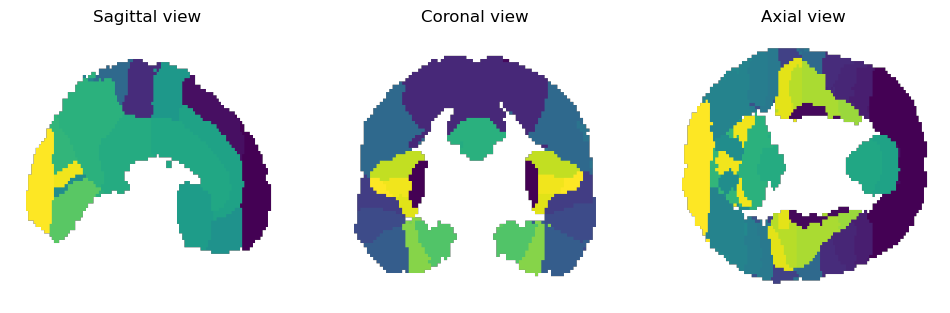

In [17]:
# Display sections of the atlas through the sagittal, coronal, and axial views, using the middle sections coordinates. 
display_fMRI_atlas(atlas_data, 'viridis')

In [18]:
# Create a dictionary with the region index as the key and the region name as the value. 
region_dict = {i: label for i, label in enumerate(atlas.labels)}
region_dict

{0: 'Background',
 1: 'Frontal Pole',
 2: 'Insular Cortex',
 3: 'Superior Frontal Gyrus',
 4: 'Middle Frontal Gyrus',
 5: 'Inferior Frontal Gyrus, pars triangularis',
 6: 'Inferior Frontal Gyrus, pars opercularis',
 7: 'Precentral Gyrus',
 8: 'Temporal Pole',
 9: 'Superior Temporal Gyrus, anterior division',
 10: 'Superior Temporal Gyrus, posterior division',
 11: 'Middle Temporal Gyrus, anterior division',
 12: 'Middle Temporal Gyrus, posterior division',
 13: 'Middle Temporal Gyrus, temporooccipital part',
 14: 'Inferior Temporal Gyrus, anterior division',
 15: 'Inferior Temporal Gyrus, posterior division',
 16: 'Inferior Temporal Gyrus, temporooccipital part',
 17: 'Postcentral Gyrus',
 18: 'Superior Parietal Lobule',
 19: 'Supramarginal Gyrus, anterior division',
 20: 'Supramarginal Gyrus, posterior division',
 21: 'Angular Gyrus',
 22: 'Lateral Occipital Cortex, superior division',
 23: 'Lateral Occipital Cortex, inferior division',
 24: 'Intracalcarine Cortex',
 25: 'Frontal Medi

In [19]:
# Define a function to replace voxel values in the atlas data with RBC values from the tables. 
def replace_voxel_values_with_rbc(atlas_data, table_rbc, region_dict, model_name):

    # Copy the resampled atlas data to create a new array for RBC values. 
    atlas_rbc = atlas_data.copy()

    # Iterate through all brain regions. 
    for region_index, region_name in region_dict.items():
        if region_name in table_rbc.index:
            rbc_value = table_rbc.loc[region_name, model_name]
            atlas_rbc[atlas_data == region_index] = rbc_value
        else:
            atlas_rbc[atlas_data == region_index] = 0  # Assign 0 if the region is not found in the table. 

    return atlas_rbc

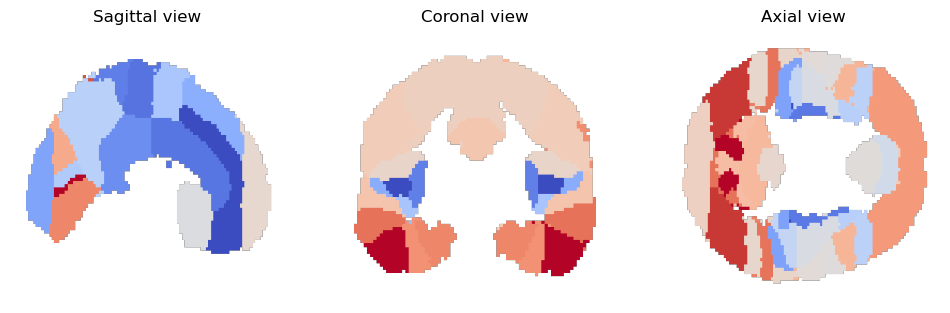

In [20]:
# Create the RBC images for the RF, SVM, and MLP models. 
atlas_rbc_rf = replace_voxel_values_with_rbc(atlas_data, table_rbc_class, region_dict, 'RF')
atlas_rbc_svm = replace_voxel_values_with_rbc(atlas_data, table_rbc_class, region_dict, 'SVM')
atlas_rbc_mlp = replace_voxel_values_with_rbc(atlas_data, table_rbc_class, region_dict, 'MLP')

# For the MLP model, display sections of the RBC image through the sagittal, coronal, and axial views, using the middle sections coordinates. 
display_fMRI_atlas(atlas_rbc_mlp, 'coolwarm')

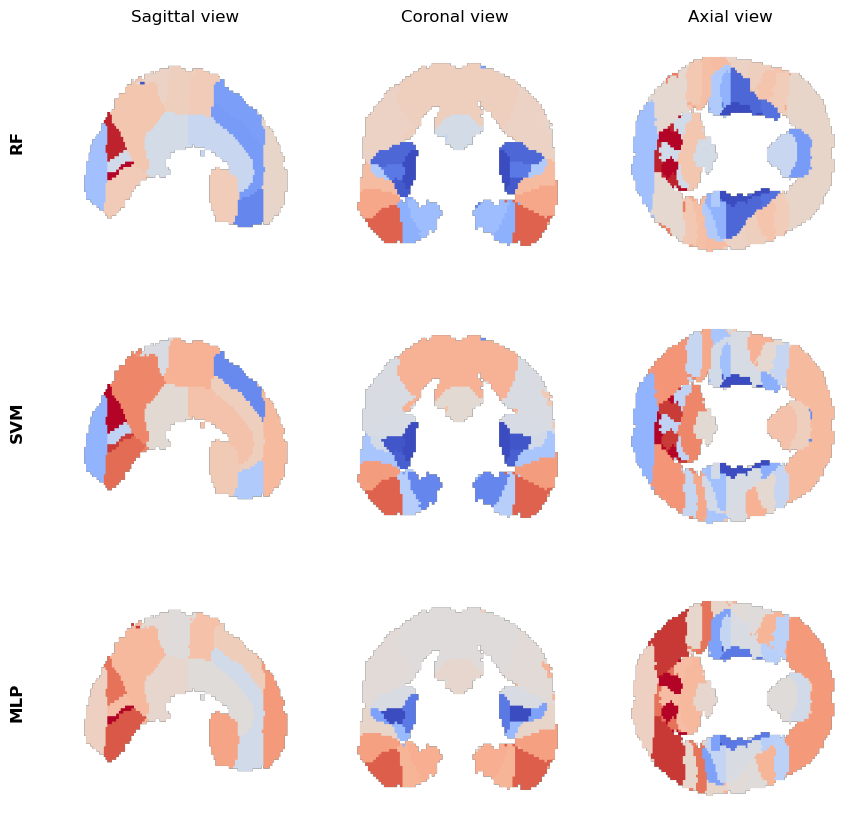

In [21]:
# Save and display the figure for the RF, SVM, and MLP models. 
image_data_list = [atlas_rbc_rf, atlas_rbc_svm, atlas_rbc_mlp]
model_names = ['RF', 'SVM', 'MLP']
model_name_positions = [0.78, 0.5, 0.22]
display_fMRI_atlas_3_models(image_data_list, model_names, model_name_positions, 'coolwarm')